In [ ]:
import pandas as pd
import numpy as np
import os
import time
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.layers import Input, Dense, Embedding, GlobalAveragePooling1D, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from datasets import load_dataset

ds = load_dataset("cnamuangtoun/resume-job-description-fit")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.csv:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

In [ ]:
train_df = ds['train'].to_pandas()
test_df = ds['test'].to_pandas()

In [ ]:
train_df.columns

Index(['resume_text', 'job_description_text', 'label'], dtype='object')

Text(0, 0.5, 'Count')

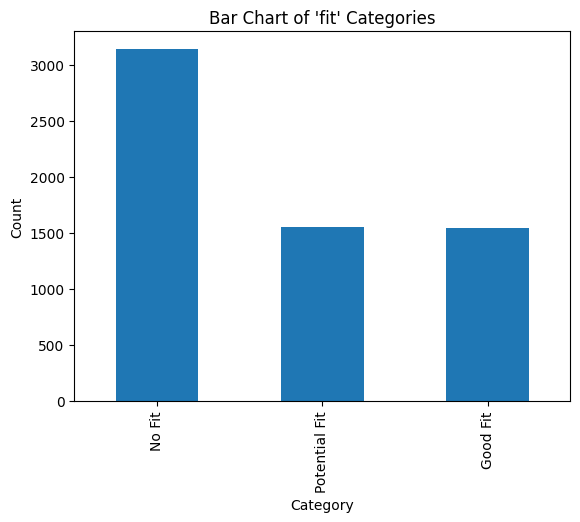

In [ ]:
train_df['label'].value_counts().plot(kind='bar')
plt.title("Bar Chart of 'fit' Categories")
plt.xlabel("Category")
plt.ylabel("Count")

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6241 entries, 0 to 6240
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   resume_text           6241 non-null   object
 1   job_description_text  6241 non-null   object
 2   label                 6241 non-null   object
dtypes: object(3)
memory usage: 146.4+ KB


In [ ]:
train_df['label'].unique()

array(['No Fit', 'Potential Fit', 'Good Fit'], dtype=object)

Text(0, 0.5, 'Count')

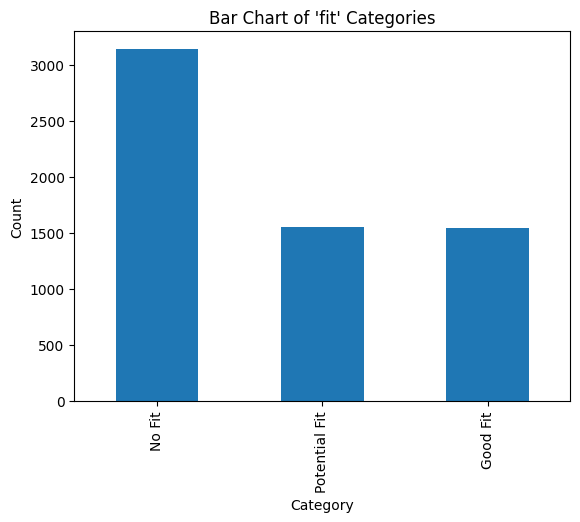

In [ ]:
train_df['label'].value_counts().plot(kind='bar')
plt.title("Bar Chart of 'fit' Categories")
plt.xlabel("Category")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

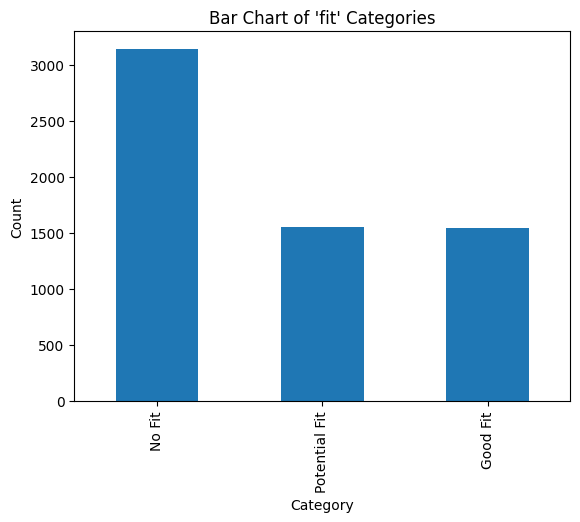

In [ ]:
train_df['label'].value_counts().plot(kind='bar')
plt.title("Bar Chart of 'fit' Categories")
plt.xlabel("Category")
plt.ylabel("Count")

In [ ]:
def change_class(row):
  if row == "Potential Fit" or row == "Good Fit":
    return "Fit"

def clean_text(text):
  text = str(text).lower()
  text = text.translate(str.maketrans("", "", string.punctuation))
  words = text.split()
  text = [word for word in words if word.isalpha() and len(word) > 1]

  return " ".join(text)

def get_len(sequence):
  return max(len(seq) for seq in sequence)


def create_sequence(data, tokenizer, resume_len=None, description_len=None):
  # cleaning text in features
  data['resume_text'] = data['resume_text'].apply(clean_text)
  data['job_description_text'] = data['job_description_text'].apply(clean_text)


  # initialize tokenizer
  tokenizer.fit_on_texts(data['resume_text'] +
                data['job_description_text'])

  # creating tokens using tokenizer
  resume_tokens = tokenizer.texts_to_sequences(data['resume_text'])
  desc_tokens = tokenizer.texts_to_sequences(data['job_description_text'])

  # getting maximum length
  if resume_len == None or description_len == None:
    resume_len = get_len(resume_tokens)
    description_len = get_len(desc_tokens)

  # creating sequences with same length
  resume_seq = pad_sequences(resume_tokens, maxlen=resume_len)
  desc_seq = pad_sequences(desc_tokens, maxlen=description_len)

  return resume_seq, desc_seq, resume_len, description_len

In [ ]:
# train_df['fit'] = train_df['fit'].apply(change_class)
# test_df['fit'] = test_df['fit'].apply(change_class)

# encoding target feature
encoder = LabelEncoder()
train_df['label'] = encoder.fit_transform(train_df['label'])
test_df['label'] = encoder.fit_transform(test_df['label'])

tokenizer = Tokenizer(oov_token="<OOV>")
# training
resume_seq, desc_seq, resume_len, description_len = create_sequence(train_df, tokenizer)

# validation
valid_resume_seq, validation_desc_seq, _, _ = create_sequence(test_df, tokenizer, resume_len, description_len)

# vocabulary size
vocab_size = len(tokenizer.word_index) + 1

In [ ]:
print(resume_len)
print(description_len)

3028
1055


In [ ]:
# building model

input_1 = Input(shape=(resume_len, ), name='resume')
input_2 = Input(shape=(description_len, ), name='description')

# embedding
emb_1 = Embedding(vocab_size, 128)(input_1)
emb_2 = Embedding(vocab_size, 128)(input_2)

# pooling
pool_1 = GlobalAveragePooling1D()(emb_1)
pool_2 = GlobalAveragePooling1D()(emb_2)

merged = Concatenate()([pool_1, pool_2])

x = Dense(128, activation='relu')(merged)
x = Dropout(0.5)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=[input_1, input_2], outputs=output)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resume (InputLayer) │ (None, 3028)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ description         │ (None, 1055)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 3028, 128) │  7,069,440 │ resume[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1055, 128) │  7,069,440 │ description[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ embedding[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ embedding_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,180,227 (54.09 MB)

 Trainable params: 14,180,227 (54.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
model.fit([resume_seq, desc_seq], train_df['label'], epochs=10,batch_size=32, validation_data=([valid_resume_seq, validation_desc_seq], test_df['label']))

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 59s 299ms/step - accuracy: 0.5002 - loss: 1.0501 - val_accuracy: 0.4872 - val_loss: 1.0473
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 59s 299ms/step - accuracy: 0.4960 - loss: 1.0446 - val_accuracy: 0.4872 - val_loss: 1.0482
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 56s 284ms/step - accuracy: 0.5143 - loss: 1.0311 - val_accuracy: 0.4872 - val_loss: 1.0483
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 69s 352ms/step - accuracy: 0.5025 - loss: 1.0387 - val_accuracy: 0.4872 - val_loss: 1.0487
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 58s 297ms/step - accuracy: 0.5117 - loss: 1.0331 - val_accuracy: 0.4872 - val_loss: 1.0597
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 58s 297ms/step - accuracy: 0.5065 - loss: 1.0398 - val_accuracy: 0.4872 - val_loss: 1.0494
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 58s 297ms/step - accuracy: 0.5079 - loss: 1.0313 - val_accuracy: 0.4872 - val_loss: 1.0578
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 57s 293ms/step - accuracy: 0.5056 - loss: 1

In [ ]:
import pickle

with open("model_type1.pkl", "wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("tokenier.pkl", "wb") as file:
  pickle.dump(tokenizer, file)

In [22]:
data = pd.read_csv("/content/job_fit_results .csv")

In [23]:
data.head()

,Unnamed: 0,job_name,company_name,location,description,role,company_url,resume,prediction
0,0,sales executive - Level Senior,Future Systems,Pune,We are looking for a high-energy Sales Executi...,sales executive,https://www.indeed.com/viewjob?jk=demo0000,An experienced AI Engineer with expertise in m...,**Analysis:**\n\nWhile the RESUME mentions AI-...
1,1,sales executive - Level Junior,AI Solutions Ltd,Pune,We are looking for a high-energy Sales Executi...,sales executive,https://www.indeed.com/viewjob?jk=demo0001,An experienced AI Engineer with expertise in m...,Fit: No Fit
2,2,sales executive - Level Mid,Neural Networks Co,Chennai,We are looking for a high-energy Sales Executi...,sales executive,https://www.indeed.com/viewjob?jk=demo0002,An experienced AI Engineer with expertise in m...,Fit: The skills mentioned in the RESUME (Pytho...
3,3,sales executive - Level Junior,Machine Learning Pro,Mumbai,We are looking for a high-energy Sales Executi...,sales executive,https://www.indeed.com/viewjob?jk=demo0003,An experienced AI Engineer with expertise in m...,Fit: The given RESUME highlights relevant tech...
4,4,sales executive - Level Junior,Innovate Labs,Pune,We are looking for a high-energy Sales Executi...,sales executive,https://www.indeed.com/viewjob?jk=demo0004,An experienced AI Engineer with expertise in m...,Fit: No Fit\n\n\nThe given RESUME is focused o...


In [25]:
data['prediction'][0]

'**Analysis:**\n\nWhile the RESUME mentions AI-related skills like machine learning, deep learning, and generative AI, it focuses more on software development, data analysis, and project management. There are no specific language or programming requirements mentioned.\n\nOn the other hand, the JOB DESCRIPTION emphasizes sales and communication skills, suggesting that the ideal candidate is a business-focused person with strong persuasion abilities.\n\n**Match:**\n\nGiven these differences, I would classify the RESUME as NOT Fitting the JOB DESCRIPTION.\n\n**Fit:** No'

In [26]:
if "No" in "No fit":
  print("yes")

yes
